Typical workflow creating a model


In [50]:
workflows= {
    1: 'get data ready (turn into tensors)',
    2: ['build or pick a trained model', 'pick loss function and optimizer', 'build training loop'], 
    3: 'fit the model and predict',
    4: 'evaluate the model',
    5: 'improve model',
    6: 'save and reload model'
}

In [51]:
def show_workflow(workflows= workflows):
    for a, b in workflows.items():

        print(a, b)

show_workflow()

1 get data ready (turn into tensors)
2 ['build or pick a trained model', 'pick loss function and optimizer', 'build training loop']
3 fit the model and predict
4 evaluate the model
5 improve model
6 save and reload model


In [52]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

PREPARING AND LOADING DATA

In [53]:
# creatnig parameters

weight= 0.7
bias= 0.3

#data

start= 0
end= 1
step= 0.01
X= torch.arange(start, end, step).unsqueeze(dim=1)
y= weight * X + bias
X

tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900],
        [0.1000],
        [0.1100],
        [0.1200],
        [0.1300],
        [0.1400],
        [0.1500],
        [0.1600],
        [0.1700],
        [0.1800],
        [0.1900],
        [0.2000],
        [0.2100],
        [0.2200],
        [0.2300],
        [0.2400],
        [0.2500],
        [0.2600],
        [0.2700],
        [0.2800],
        [0.2900],
        [0.3000],
        [0.3100],
        [0.3200],
        [0.3300],
        [0.3400],
        [0.3500],
        [0.3600],
        [0.3700],
        [0.3800],
        [0.3900],
        [0.4000],
        [0.4100],
        [0.4200],
        [0.4300],
        [0.4400],
        [0.4500],
        [0.4600],
        [0.4700],
        [0.4800],
        [0.4900],
        [0.5000],
        [0.5100],
        [0.5200],
        [0.5300],
        [0.5400],
        [0

In [54]:
print(len(X), len(y))

100 100


SPLITTING DATA INTO TRAIN VALID TEST

In [55]:
from sklearn.model_selection import train_test_split

X_train, temp_X, y_train, temp_y= train_test_split(X, y, test_size=0.30, random_state=0)


X_valid, X_test, y_valid, y_test= train_test_split(temp_X, temp_y, test_size=0.50, random_state=0)

In [56]:
print(len(X_train), len(X_valid), len(X_test), len(y_train), len(y_valid), len(y_test))

70 15 15 70 15 15


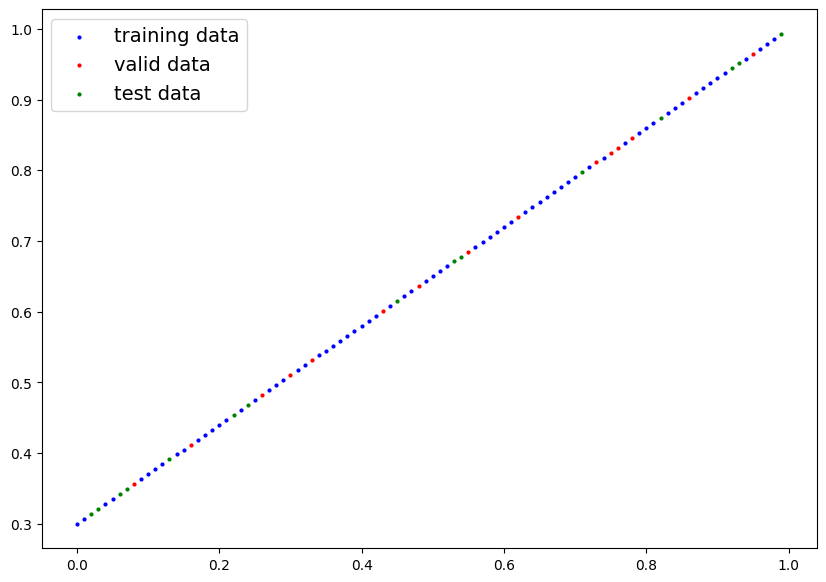

In [57]:
def plot_predictions(
        train_data= X_train,
        train_labels= y_train,
        valid_data= X_valid,
        valid_labels= y_valid,
        test_data= X_test,
        test_labels= y_test,
        prediction_data= None,
        prediction= None):
    
    '''Plots traning, valid and test data'''
    
    plt.figure(figsize=(10, 7))

    plt.scatter(train_data, train_labels, c='b', s=4, label="training data")
    plt.scatter(valid_data, valid_labels, c='r', s=4, label="valid data")
    plt.scatter(test_data, test_labels, c='g', s=4, label="test data")
    
    if prediction is not None and prediction_data is not None:
        plt.scatter(prediction_data, prediction, c='y', s=4, label='predictions')

    plt.legend(prop= {'size': 14})
    

plot_predictions()

Building model

In [58]:

class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.weight = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

        self.bias= nn.Parameter( torch.randn(1, requires_grad=True, dtype=torch.float))


    def forward(self, x: torch.Tensor) -> torch.Tensor: 
        return self.weight * x + self.bias


1. torch.nn.Parameter - vilka parameter vår modell ska använda / layers?
2. torch.optim - pytorchs opimizers

In [59]:
SEED=0

torch.manual_seed(SEED)
model=LinearRegression()

print(list(model.parameters()))


#samma:

print(model.state_dict())

[Parameter containing:
tensor([1.5410], requires_grad=True), Parameter containing:
tensor([-0.2934], requires_grad=True)]
OrderedDict({'weight': tensor([1.5410]), 'bias': tensor([-0.2934])})


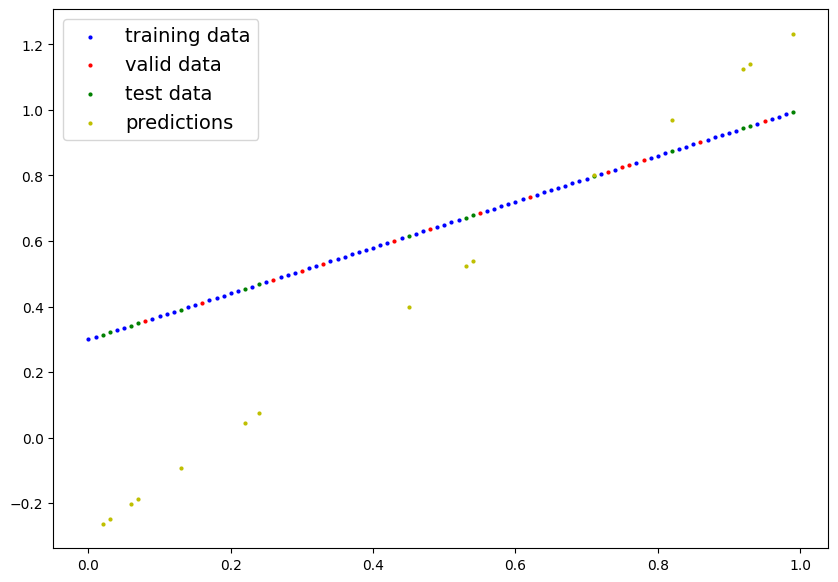

In [60]:
with torch.inference_mode(): #viktigt att använda när man gör eval, stänger av gradient som uppdaterar weight
    y_preds = model(X_test)

plot_predictions(prediction=y_preds, prediction_data=X_test)

 ett sätt att mäta hur fel vår model har är vi en lossfunction
 Kan även kallas för: 
 1. cost function
 2. criterion.

In [61]:
loss_fn= nn.L1Loss()

optimizer= torch.optim.SGD(params=model.parameters(), lr=0.001) 

Build training and testing loop

1. Loop thru data

2. forward pass

3. calculate loss (comparare forward pass predictions to ground truth labels)

4. optimizer zero grad

5. loss backkwardspass (move backwards thru network to calculate the gradients of each of the parameters of our model with respect to the loss (**backpropagation**))

6. optimizer step (use optimizer to adjust our models parameters to improve loss)

In [62]:
epochs=10000

epoch_count=[]
loss_values= []
val_loss_values=[]

for epoch in range(epochs):
    
    # 1. set model in training mode
    model.train()

    # 2. forward pass
    y_preds= model(X_train)

    # 3. calculate loss
    loss = loss_fn(y_preds, y_train)
    
    if epoch % 1000 == 0:
        print(epoch, ' train loss:', loss.item())
    
    # 4. opimizer zero grad
    optimizer.zero_grad()

    # 5. perform backpropagation
    loss.backward()

    # 6. step the opimtizer (perform gradient decent)

    optimizer.step()


    #evaluations
    model.eval()
    with torch.inference_mode():
    
        val_preds= model(X_valid)
        val_loss= loss_fn(val_preds, y_valid)
        if epoch % 1000 == 0: 
            epoch_count.append(epoch)
            loss_values.append(loss)
            val_loss_values.append(val_loss)

            print(epoch, 'val loss:', val_loss.item())


model.state_dict()

0  train loss: 0.24138140678405762
0 val loss: 0.2094222605228424
1000  train loss: 0.1735609620809555
1000 val loss: 0.16163891553878784
2000  train loss: 0.12799124419689178
2000 val loss: 0.11927645653486252
3000  train loss: 0.08245201408863068
3000 val loss: 0.0768221989274025
4000  train loss: 0.036918215453624725
4000 val loss: 0.034374188631772995
5000  train loss: 0.0009401108254678547
5000 val loss: 0.0003263255057390779
6000  train loss: 0.0009401108254678547
6000 val loss: 0.0003263255057390779
7000  train loss: 0.0009401108254678547
7000 val loss: 0.0003263255057390779
8000  train loss: 0.0009401108254678547
8000 val loss: 0.0003263255057390779
9000  train loss: 0.0009401108254678547
9000 val loss: 0.0003263255057390779


OrderedDict([('weight', tensor([0.7000])), ('bias', tensor([0.2991]))])

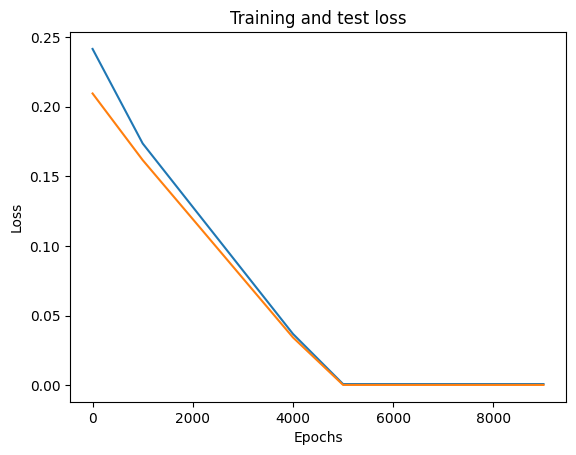

In [63]:
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label='Train values')
plt.plot(epoch_count, np.array(torch.tensor(val_loss_values).numpy()), label='Valid values')
plt.title('Training and test loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.show()


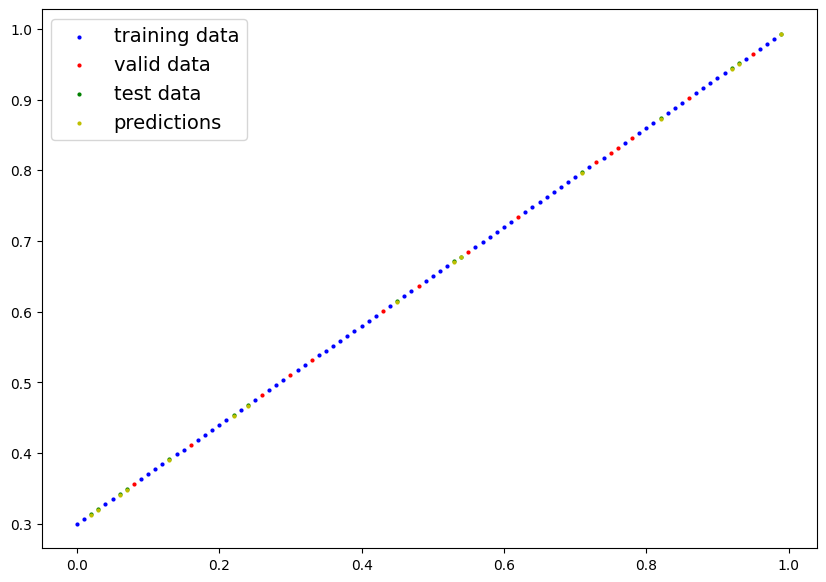

In [64]:
model.eval()
with torch.inference_mode():
    
    val_preds= model(X_test)
    val_loss= loss_fn(val_preds, y_test)
    
plot_predictions(prediction=val_preds, prediction_data=X_test)

SAVING MODEL

Det finns 3 huvudmetoder att spara och ladda en mdodel i pytorch.

1. **torch.save()** - sparar ett pytorch objekt i pythons pickle format

2. **torch.load()** - laddar ett sparat pytorch objekt

3. **torch.nn.Module.load_state_dict()** - ladar en modells sparade state dictionary (weights, bias) ?

In [65]:
model.state_dict()

OrderedDict([('weight', tensor([0.7000])), ('bias', tensor([0.2991]))])

In [66]:
from pathlib import Path

MODEL_DIR= Path('models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path= MODEL_DIR / 'model_0.pth'

torch.save(model.state_dict(), model_path)

print('modellen sparad till:', model_path)

modellen sparad till: models\model_0.pth


In [67]:

loaded_model= LinearRegression()

loaded_model.load_state_dict(torch.load(model_path))


<All keys matched successfully>

In [68]:
loaded_model.state_dict()

OrderedDict([('weight', tensor([0.7000])), ('bias', tensor([0.2991]))])

In [69]:
loaded_model.eval()

with torch.inference_mode():
    loaded_model_preds = loaded_model(X_test)

loaded_model_preds

tensor([[0.3131],
        [0.8731],
        [0.3901],
        [0.6701],
        [0.3411],
        [0.6141],
        [0.9921],
        [0.9431],
        [0.4671],
        [0.3201],
        [0.9501],
        [0.4531],
        [0.6771],
        [0.3481],
        [0.7961]])

In [70]:
val_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

ALLT IGEN

In [71]:
import torch
import matplotlib.pyplot as plt
from torch import nn

In [72]:
device= 'cuda' if torch.cuda.is_available() else 'cpu'
print('using device:', device)

using device: cpu


1. DATA

In [73]:
weight= 0.7
bias= 0.3

start= 0
end= 1
step= 0.02

X= torch.arange(start, end, step).unsqueeze(dim=1)
y= weight * X + bias


    
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [74]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test= train_test_split(X, y, random_state=0, test_size=0.2, shuffle=False)

print(len(X_train), len(y_train), len(X_test), len(y_test))

40 40 10 10


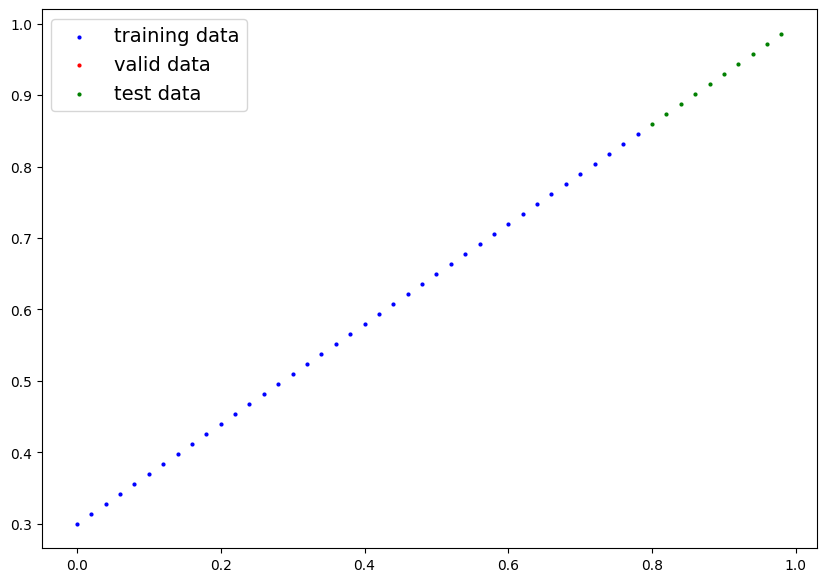

In [75]:
plot_predictions(train_data=X_train, train_labels=y_train, valid_data=None, valid_labels=None, test_data=X_test, test_labels=y_test)

MODEL BUILDING

In [76]:
class LinearRegression2(nn.Module):
   def __init__(self):
      super().__init__()
      #  self.weight= nn.Parameter(torch.rand(1, requires_grad=True, dtype=torch.float))
      #  self.bias= nn.Parameter(torch.rand(1, requires_grad=True, dtype=torch.float))

      self.linear_layer= nn.Linear(in_features=1, out_features=1, dtype=torch.float) # <- layer

   def forward(self, x: torch.Tensor) -> torch.Tensor:
      # return self.weight * x + self.bias
      return self.linear_layer(x)
    


In [77]:
torch.manual_seed(42)
model_1= LinearRegression2()

model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

TRAINING MODEL

In [78]:
device= 'cuda' if torch.cuda.is_available() else 'cpu'

model_1.to(device)
next(model_1.parameters()).device

device(type='cpu')

In [79]:
# vi behöver loss fn, optimizer, training loop, testing loop


loss_fn1= nn.L1Loss()
optimizer_1= torch.optim.SGD(params= model_1.parameters(), lr=0.01)

In [81]:
torch.manual_seed(42)

epochs= 200

X_train= X_train.to(device)
y_train= y_train.to(device)
X_test= X_test.to(device)
y_test= y_test.to(device)

for epoch in range(epochs):
    #set in traning mode
    model.train()

    #1. forwardpass
    preds= model_1(X_train)

    #2. calculate loss

    loss= loss_fn1(preds, y_train)

    #3. optimizer zero grad

    optimizer_1.zero_grad()

    #4. perform backpropagation

    loss.backward()

    #5. optim step
    
    optimizer_1.step()

    #Eval/ testing

    model_1.eval()
    with torch.inference_mode():
        test_preds= model_1(X_test)

        test_loss= loss_fn1(test_preds, X_test)

    
    if epoch % 10 == 0:
        print(f'Epoch: {epoch} | Loss: {loss:.6f} | Test loss: {test_loss:.6f}')

Epoch: 0 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 10 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 20 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 30 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 40 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 50 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 60 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 70 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 80 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 90 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 100 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 110 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 120 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 130 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 140 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 150 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 160 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 170 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 180 | Loss: 0.001265 | Test loss: 0.021346
Epoch: 190 | Loss: 0.001265 | Test loss: 0.021346


In [82]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

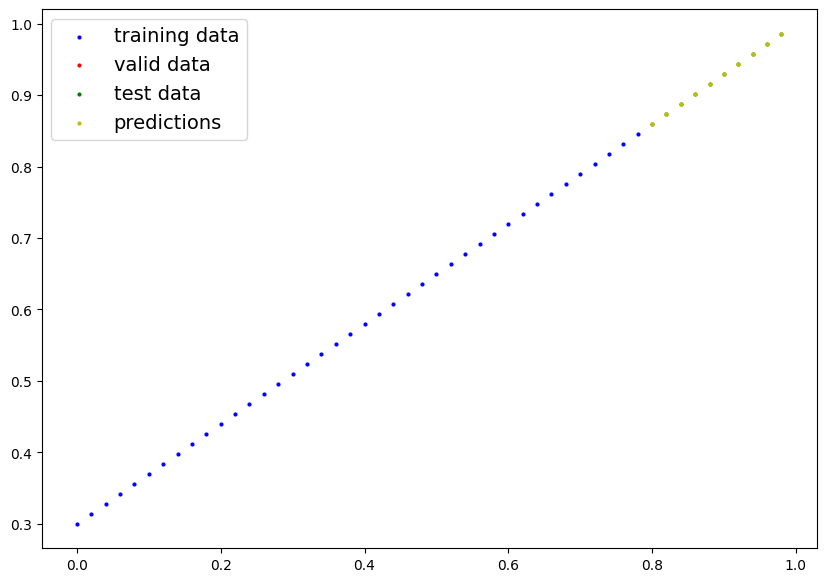

In [84]:
model_1.eval()
with torch.inference_mode():
    test_preds= model_1(X_test)

plot_predictions(train_data=X_train, train_labels=y_train,
                 valid_data=None, valid_labels=None,
                 test_data=X_test, test_labels=y_test,
                 prediction_data=X_test, prediction=test_preds)

SAVING AND LOADING MODEL

In [ ]:
dir= Path(MODEL_DIR)
#dir.mkdir(parent=True, exist_ok=True)

path= MODEL_DIR / 'model_1.pth'



torch.save(model_1.state_dict(), path)

print('Modellen sparad till', path)

Modellen sparad till models\model_1.pth


In [90]:
loaded_model_1= LinearRegression2()

loaded_model_1.load_state_dict(torch.load(path))

<All keys matched successfully>